In [1]:
import warnings
warnings.simplefilter('ignore')
import glob
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import sunpy.map
from sunpy.time import parse_time
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import PowerNorm
from tqdm import tqdm

data_dir = '/home/mnedal/data'

In [2]:
date     = '2025-10-06'
# target   = '2025-10-06T08:58:05' # --> west
target   = '2025-10-06T08:59:45' # --> centre

CHANNELS = {'R': 211, 'G': 193, 'B': 171}   # colour -> AIA channel
year, month, day = date.split('-')
print(year, month, day)

ROIS = {
    'west_limb': dict(left=800,  right=1210, bottom=-300, top=300),
    'central':   dict(left=-120, right=500,  bottom=-200, top=400),
}

2025 10 06


In [3]:
def load_channel(channel):
    y, m, d = date.split('-')
    files = sorted(glob.glob(
        f'{data_dir}/AIA/{channel}A/highres/lv15/'
        f'aia.lev15.{channel}A_{y}_{m}_{d}T*_lev15*.fits'))
    if not files:
        raise FileNotFoundError(f'No files for {channel} A on {date}.')
    return sunpy.map.Map(files, sequence=True)


def running_ratio_map(sequence, target_time, lag=1, denom_floor=1.0):
    """Frame / previous frame at the nearest frame to target_time."""
    t   = parse_time(target_time)
    idx = int(np.argmin([abs(mp.date - t) for mp in sequence.maps]))
    if idx < lag:
        raise ValueError(f'Frame {idx} has no frame {lag} step(s) earlier.')
    cur, prev = sequence[idx], sequence[idx - lag]
    # NaN out near-zero/off-limb denominators so they map to black rather than blow up
    denom = np.where(prev.data > denom_floor, prev.data, np.nan)
    rmap  = sunpy.map.Map(cur.data / denom, cur.meta)
    rmap.plot_settings['norm'] = colors.Normalize()  # avoid inherited-stretch repr crash
    return rmap, cur.date


def crop_to_roi(rmap, box):
    frame = rmap.coordinate_frame
    bl = SkyCoord(box['left']  * u.arcsec, box['bottom'] * u.arcsec, frame=frame)
    tr = SkyCoord(box['right'] * u.arcsec, box['top']    * u.arcsec, frame=frame)
    return rmap.submap(bl, top_right=tr)


def scale_to_unit(data, method='percentile',
                  plo=0.5, phi=99.5, lo=0.5, hi=2.0, gamma=0.5):
    """Map a ratio array into [0, 1] for RGB display."""
    a = np.asarray(data, dtype=float)
    if method == 'percentile':
        vmin, vmax = np.nanpercentile(a, [plo, phi])
        out = (a - vmin) / (vmax - vmin)
    elif method == 'fixed':
        out = (a - lo) / (hi - lo)
    elif method == 'powernorm':
        out = PowerNorm(gamma=gamma, vmin=lo, vmax=hi, clip=True)(a)
    else:
        raise ValueError("method must be 'percentile', 'fixed', or 'powernorm'.")
    return np.clip(np.nan_to_num(out, nan=0.0), 0, 1)


def build_rgb(r_map, g_map, b_map, method='percentile', **kw):
    # All three are AIA L1.5 on the same grid; trim to the common shape as a guard
    ny = min(m.data.shape[0] for m in (r_map, g_map, b_map))
    nx = min(m.data.shape[1] for m in (r_map, g_map, b_map))
    r = scale_to_unit(r_map.data[:ny, :nx], method, **kw)
    g = scale_to_unit(g_map.data[:ny, :nx], method, **kw)
    b = scale_to_unit(b_map.data[:ny, :nx], method, **kw)
    rgb = np.dstack([r, g, b])
    ref = sunpy.map.Map(g_map.data[:ny, :nx], g_map.meta)  # G carries the reference WCS
    ref.plot_settings['norm'] = colors.Normalize()
    return rgb, ref


def plot_rgb(rgb, ref_map, title=''):
    fig = plt.figure(figsize=[7,7])
    ax  = fig.add_subplot(projection=ref_map)
    ax.imshow(rgb, origin='lower')
    ref_map.draw_limb(axes=ax, color='white', alpha=0.5)
    ax.grid(False)
    ax.set_title(title)
    ax.set_xlabel('Solar X (arcsec)')
    ax.set_ylabel('Solar Y (arcsec)')
    return fig, ax

In [4]:
# --- run ---
sequences = {c: load_channel(ch) for c, ch in CHANNELS.items()}

ratio_maps, times = {}, {}

with tqdm(total=len(CHANNELS), desc='Channels plotted') as pbar:
    for c in CHANNELS:
        ratio_maps[c], times[c] = running_ratio_map(sequences[c], target, lag=12)
        pbar.update(1)

print('Frame times:', {CHANNELS[c]: str(times[c]) for c in CHANNELS})

region = 'central'   # 'west_limb' or 'central'
method = 'powernorm'   # 'percentile' | 'fixed' | 'powernorm'

cropped = {c: crop_to_roi(ratio_maps[c], ROIS[region]) for c in CHANNELS}
rgb, ref = build_rgb(cropped['R'], cropped['G'], cropped['B'],
                     method=method, gamma=0.5, lo=0.5, hi=2.0)

Channels plotted: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:24<00:00,  8.19s/it]


Frame times: {211: '2025-10-06T08:59:45.630', 193: '2025-10-06T08:59:40.840', 171: '2025-10-06T08:59:45.350'}


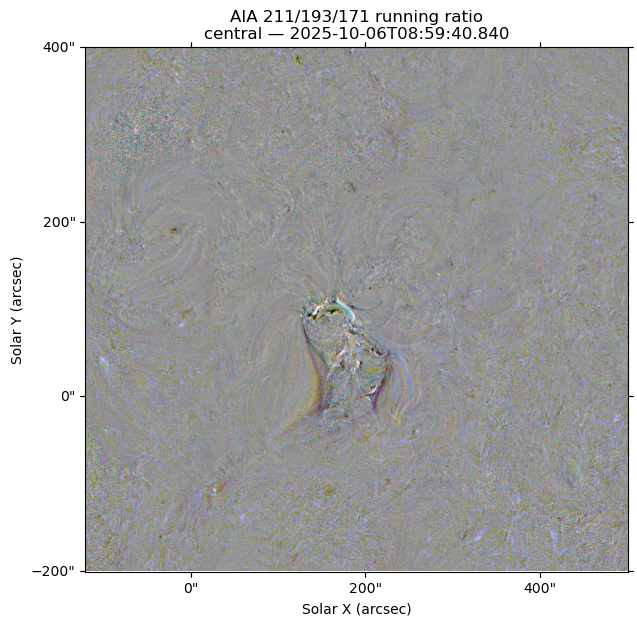

In [5]:
plot_rgb(rgb, ref,
         title=f'AIA 211/193/171 running ratio\n{region} — {times["G"]}')
plt.show()

In [24]:
import os
from sunpy.time import parse_time

def plot_rgb(rgb, ref_map, region='central', export=False, title='', dpi=150):
    fig = plt.figure(figsize=[7, 7], layout='constrained')  # constrained + fixed size -> deterministic PNG dims
    ax  = fig.add_subplot(projection=ref_map)
    ax.imshow(rgb, origin='lower')
    ref_map.draw_limb(axes=ax, color='white', alpha=0.5)
    ax.grid(False)
    ax.set_title(title)
    ax.set_xlabel('Solar X (arcsec)')
    ax.set_ylabel('Solar Y (arcsec)')
    if export:
        outdir = f'./data/AIA_RGB/{region}'
        os.makedirs(outdir, exist_ok=True)
        fname = ref_map.date.strftime('%Y%m%dT%H%M%S')
        fig.savefig(f'{outdir}/{fname}.png', format='png', dpi=dpi)  # no bbox_inches='tight'
        plt.close(fig)
    return fig, ax


def frame_indices_in_window(sequence, start, end):
    s, e = parse_time(start), parse_time(end)
    return [i for i, mp in enumerate(sequence.maps) if s <= mp.date <= e]


def ratio_at_index(sequence, idx, lag=1, denom_floor=1.0):
    if idx < lag:
        return None
    cur, prev = sequence[idx], sequence[idx - lag]
    denom = np.where(prev.data > denom_floor, prev.data, np.nan)
    rmap  = sunpy.map.Map(cur.data / denom, cur.meta)
    rmap.plot_settings['norm'] = colors.Normalize()
    return rmap


def make_nearest_finder(sequence):
    """O(log N) nearest-frame lookup; avoids O(N^2) over a full-day window."""
    t = np.array([mp.date.unix for mp in sequence.maps])
    def find(when):
        w = when.unix
        j = np.searchsorted(t, w)
        if j == 0:
            return 0
        if j >= len(t):
            return len(t) - 1
        return j if (t[j] - w) < (w - t[j - 1]) else j - 1
    return find


def process_window(sequences, start, end, region,
                   method='powernorm', lag=1, dpi=150, **kw):
    ref_seq   = sequences['G']                       # G/193 drives the timeline
    find_r    = make_nearest_finder(sequences['R'])
    find_b    = make_nearest_finder(sequences['B'])
    box       = ROIS[region]
    idxs      = frame_indices_in_window(ref_seq, start, end)

    with tqdm(total=len(idxs), desc='Timestamps processed') as pbar:
        for gi in idxs:
            g_ratio = ratio_at_index(ref_seq, gi, lag)
            if g_ratio is None:                          # no previous frame for the very first
                continue
            t       = ref_seq[gi].date
            r_ratio = ratio_at_index(sequences['R'], find_r(t), lag)
            b_ratio = ratio_at_index(sequences['B'], find_b(t), lag)
            if r_ratio is None or b_ratio is None:
                continue
    
            cr  = crop_to_roi(r_ratio, box)
            cg  = crop_to_roi(g_ratio, box)
            cb  = crop_to_roi(b_ratio, box)
            rgb, ref = build_rgb(cr, cg, cb, method=method, **kw)
            plot_rgb(rgb, ref, region=region, export=True, dpi=dpi,
                     title=f'AIA 211/193/171 running ratio \n{region} — {ref.date}')
            pbar.update(1)

In [25]:
# --- run ---
sequences = {c: load_channel(ch) for c, ch in CHANNELS.items()}

process_window(sequences,
               start='2025-10-06T08:30:00',
               end='2025-10-06T10:30:00',
               region='west_limb',
               method='powernorm', gamma=0.5, lo=0.5, hi=2.0,
               dpi=150)

Timestamps processed: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 599/600 [32:22<00:03,  3.24s/it]
